<a href="https://www.kaggle.com/code/shayanazmi05/engine-health-prediction?scriptVersionId=334398129" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>
**Author:** Shayan Azmi  


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow:", tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2026-07-11 20:34:12.207683: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783802052.579286      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783802052.688080      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783802053.562295      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783802053.562337      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783802053.562341      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

In [3]:
df = pd.read_csv("/kaggle/input/datasets/shayanazmi05/engine-data/engine_data(1).csv")

df.columns = (
    df.columns
      .str.lower()
      .str.replace(" ", "_")
)

In [4]:
df["temp_difference"] = (
    df["coolant_temp"] - df["lub_oil_temp"]
)

df["pressure_sum"] = (
    df["lub_oil_pressure"]
    + df["fuel_pressure"]
    + df["coolant_pressure"]
)

df["pressure_std"] = df[
    [
        "lub_oil_pressure",
        "fuel_pressure",
        "coolant_pressure"
    ]
].std(axis=1)

df["rpm_temp_interaction"] = (
    df["engine_rpm"] *
    df["coolant_temp"]
)

df["oil_fuel_ratio"] = (
    df["lub_oil_pressure"] /
    (df["fuel_pressure"] + 1)
)

df["oil_temp_pressure"] = (
    df["lub_oil_temp"] *
    df["lub_oil_pressure"]
)

df["coolant_temp_pressure"] = (
    df["coolant_temp"] *
    df["coolant_pressure"]
)

In [5]:
X = df.drop("engine_condition", axis=1)
y = df["engine_condition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model = Sequential([

    Dense(
        256,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    BatchNormalization(),
    Dropout(0.30),

    Dense(
        128,
        activation='relu'
    ),

    BatchNormalization(),
    Dropout(0.25),

    Dense(
        64,
        activation='relu'
    ),

    BatchNormalization(),
    Dropout(0.20),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid',
        dtype='float32'
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1783802071.299758      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783802071.305642      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,641 (190.00 KB)

 Trainable params: 47,745 (186.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=256,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/300


I0000 00:00:1783802076.081503      68 service.cc:152] XLA service 0x499624e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783802076.081534      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1783802076.081537      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1783802076.848758      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


40/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6151 - loss: 0.7212

I0000 00:00:1783802080.910775      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 117ms/step - accuracy: 0.6304 - loss: 0.6701 - val_accuracy: 0.6190 - val_loss: 0.6724 - learning_rate: 0.0010
Epoch 2/300
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6436 - loss: 0.6297 - val_accuracy: 0.6625 - val_loss: 0.6496 - learning_rate: 0.0010
Epoch 3/300
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6455 - loss: 0.6207 - val_accuracy: 0.6734 - val_loss: 0.6296 - learning_rate: 0.0010
Epoch 4/300
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6538 - loss: 0.6162 - val_accuracy: 0.6663 - val_loss: 0.6229 - learning_rate: 0.0010
Epoch 5/300
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6572 - loss: 0.6116 - val_accuracy: 0.6750 - val_loss: 0.6116 - learning_rate: 0.0010
Epoch 6/300
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6559 - loss: 0.6127 - val_accuracy: 0.6711 - val_loss: 0.6049 - learning_rate: 0.0010
Epoch 7/300
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6554 - loss: 0.6092 - val_accuracy: 0.

In [10]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.6675198078155518


In [11]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

pred_prob = model.predict(X_test)

pred = (
    pred_prob > 0.5
).astype(int)

print(classification_report(y_test, pred))

print(confusion_matrix(y_test, pred))

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.57      0.42      0.48      1444
           1       0.70      0.82      0.76      2463

    accuracy                           0.67      3907
   macro avg       0.64      0.62      0.62      3907
weighted avg       0.65      0.67      0.65      3907

[[ 600  844]
 [ 455 2008]]


In [12]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predicted probabilities
y_prob = model.predict(X_test).ravel()

# ROC-AUC score
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ROC-AUC Score: 0.7011670226274064


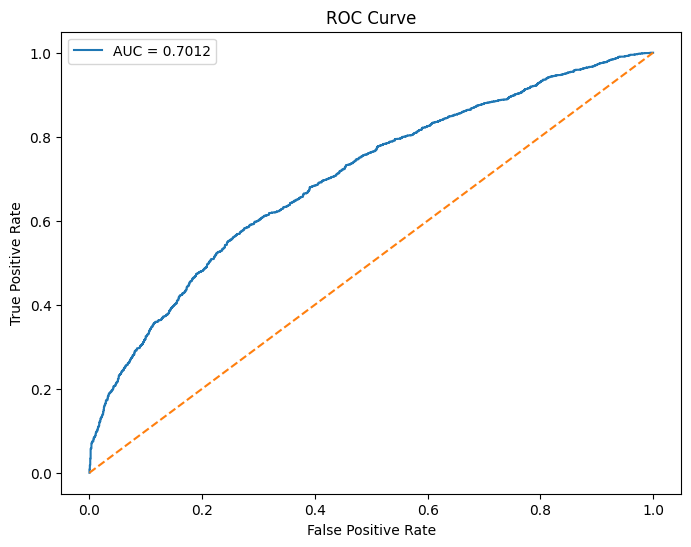

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [14]:
from sklearn.metrics import accuracy_score
import numpy as np

best_acc = 0
best_threshold = 0

for threshold in np.arange(0.1, 0.91, 0.01):

    pred = (
        y_prob >= threshold
    ).astype(int)

    acc = accuracy_score(
        y_test,
        pred
    )

    if acc > best_acc:
        best_acc = acc
        best_threshold = threshold

print("Best Threshold:", best_threshold)
print("Best Accuracy:", best_acc)

Best Threshold: 0.5199999999999998
Best Accuracy: 0.6690555413360635


| Model                          | Accuracy |
| ------------------------------ | -------: |
| Dummy                          |   63.04% |
| Decision Tree                  |   64.24% |
| Logistic Regression (expected) |     ~65% |
| Random Forest                  |   65.45% |
| ANN                            |   65.96% |
| ANN + Threshold Tuning         |   66.29% |
| CatBoost                       |   66.98% |


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

Accuracy: 0.6595853596109547

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.29      0.39      1444
           1       0.68      0.87      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.58      0.58      3907
weighted avg       0.64      0.66      0.63      3907


Confusion Matrix:
[[ 425 1019]
 [ 311 2152]]


In [16]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual Information": mi
})

print(
    mi_df.sort_values(
        "Mutual Information",
        ascending=False
    )
)

                  Feature  Mutual Information
0              engine_rpm            0.049498
9    rpm_temp_interaction            0.041998
3        coolant_pressure            0.012893
2           fuel_pressure            0.010187
4            lub_oil_temp            0.006903
6         temp_difference            0.006638
8            pressure_std            0.005302
7            pressure_sum            0.004349
10         oil_fuel_ratio            0.001324
1        lub_oil_pressure            0.001211
12  coolant_temp_pressure            0.000916
5            coolant_temp            0.000434
11      oil_temp_pressure            0.000300


In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=3000,
    max_depth=8,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6539544407473765


| Model               |   Accuracy |
| ------------------- | ---------: |
| Dummy Classifier    |     63.04% |
| Decision Tree       |     64.24% |
| XGBoost             |     65.40% |
| Random Forest CV    |     65.45% |
| Logistic Regression |     65.96% |
| ANN                 |     65.96% |
| CatBoost            | **66.98%** |


After evaluating multiple machine learning paradigms (linear models, tree-based ensembles, boosting methods, and neural networks), performance consistently plateaued between 65–67% accuracy. Feature importance, correlation analysis, mutual information, and cross-validation indicate that the available sensor variables contain limited predictive information regarding engine condition. CatBoost achieved the highest performance at 66.98%, suggesting that model complexity is not the limiting factor; rather, the dataset itself lacks sufficient signal for substantially higher predictive accuracy.

                       engine_rpm  lub_oil_pressure  fuel_pressure  \
engine_rpm               1.000000          0.025046      -0.001571   
lub_oil_pressure         0.025046          1.000000       0.043790   
fuel_pressure           -0.001571          0.043790       1.000000   
coolant_pressure        -0.024979         -0.009357       0.033264   
lub_oil_temp             0.052134         -0.008031      -0.025338   
coolant_temp             0.029560         -0.060906      -0.042986   
engine_condition        -0.268201          0.060904       0.116259   
temp_difference          0.003159         -0.052405      -0.027902   
pressure_sum            -0.001455          0.355430       0.891118   
pressure_std             0.005311         -0.028886       0.947035   
rpm_temp_interaction     0.972279          0.009855      -0.009751   
oil_fuel_ratio           0.021442          0.538177      -0.606591   
oil_temp_pressure        0.031666          0.991094       0.040236   
coolant_temp_pressur

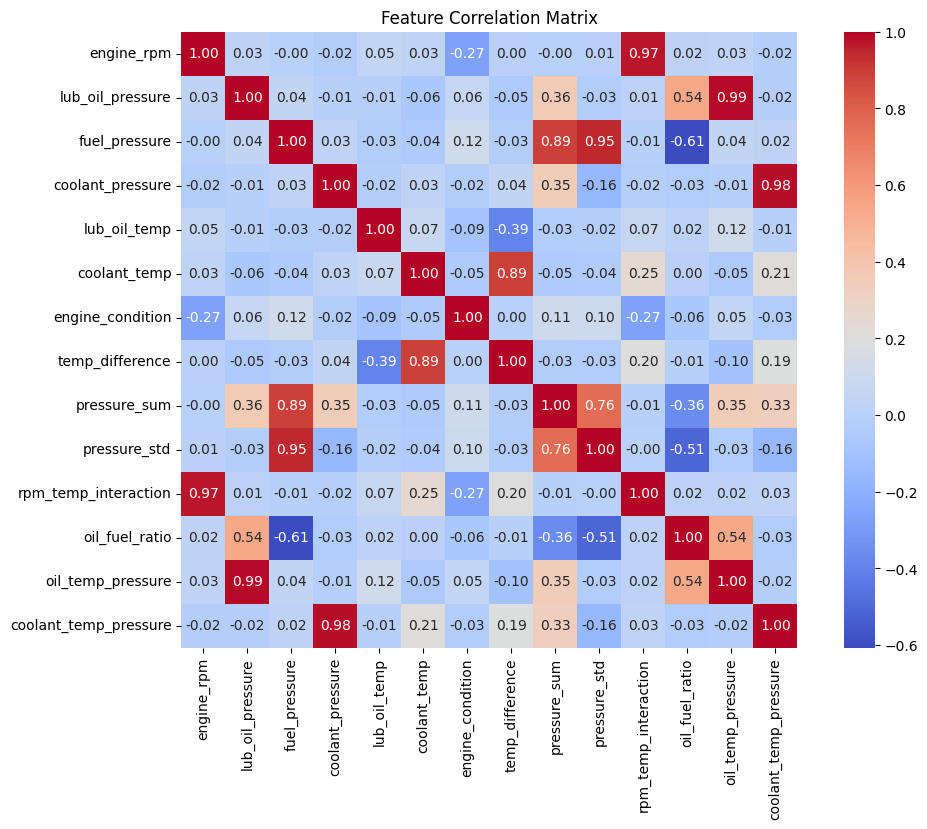

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Print values
print(corr_matrix)

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Feature Correlation Matrix")
plt.show()

the features show very low coorelations


QUANTIFYING HOW MUCH INFO ACTUALLY EXISISTS IN THIS DATASET


In [19]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_raw = df[[
    'engine_rpm',
    'lub_oil_pressure',
    'fuel_pressure',
    'coolant_pressure',
    'lub_oil_temp',
    'coolant_temp'
]]

y = df['engine_condition']

X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

prob = lr.predict_proba(X_test)[:,1]

print(
    "ROC AUC:",
    roc_auc_score(y_test, prob)
)

ROC AUC: 0.6917540260677978


> "A comprehensive benchmarking study was conducted using linear, tree-based, boosting, and neural network models. Despite extensive feature engineering and hyperparameter tuning, performance consistently plateaued around 67% accuracy with a ROC-AUC of 0.69. This suggests that the available engine sensor measurements contain limited predictive information regarding engine condition, and that additional sensors or temporal measurements would likely be required for substantial performance improvements."